# Dự đoán Độ phổ biến Sản phẩm trên Amazon

## 1. Giới thiệu
Trong notebook này, chúng ta sẽ xây dựng và tinh chỉnh các mô hình học máy để dự đoán **độ phổ biến** của các sản phẩm trên Amazon. Độ phổ biến được đo lường thông qua sản lượng bán hàng (sales volume), đã được tiền xử lý thành giá trị số thông qua phép biến đổi logarit (log-transformed) để giảm thiểu độ lệch và tối ưu cho quá trình hội tụ của mô hình.

### Mục tiêu cốt lõi:
- Xây dựng các mô hình hồi quy (Linear Regression, Random Forest, Gradient Boosting) để ước lượng doanh số dự kiến dựa trên bộ đặc trưng đa dạng (giá bán, mức giảm giá, đánh giá, phí giao hàng và danh mục sản phẩm).
- Nhận diện và phân tích mức độ ảnh hưởng của từng yếu tố đến sự thành công của sản phẩm thông qua biểu đồ **Feature Importance**.
- Áp dụng chuẩn mực đánh giá chuyên nghiệp bằng cách sử dụng **Tập kiểm định (Validation set)** kết hợp GridSearchCV để tìm kiếm siêu tham số, đảm bảo mô hình không bị quá khớp (overfitting).
- Đánh giá hiệu suất cuối cùng trên **Tập kiểm tra (Test set)** độc lập và trực quan hóa chi tiết các độ đo sai số (Predicted vs Actual, Residuals).

### Nguồn dữ liệu:
Dữ liệu đã trải qua toàn bộ quy trình tiền xử lý, làm sạch, trích xuất đặc trưng (Feature Engineering) và biến đổi qua Pipeline hoàn chỉnh:
- `train.csv` (70%): Tập dữ liệu dùng để huấn luyện mô hình.
- `val.csv` (15%): Tập dữ liệu kiểm định dùng để tinh chỉnh siêu tham số.
- `test.csv` (15%): Tập dữ liệu kiểm tra độc lập dùng để đánh giá hiệu năng thực tế.
- `sales_prediction_pipeline.joblib`: Bộ pipeline chứa các quy tắc chuẩn hóa và mã hóa, dùng để khôi phục cấu trúc đặc trưng ban đầu.


## 2. Cài đặt và Tải dữ liệu

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import PredefinedSplit, cross_val_score, GridSearchCV, learning_curve
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import xgboost as xgb
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline as SkPipeline
import warnings
import joblib
import os

warnings.filterwarnings('ignore')

sns.set_theme(style="white", palette="viridis")
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Liberation Sans', 'sans-serif']
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

In [2]:
# Định nghĩa OutlierClipper để load được file Pipeline
class OutlierClipper(BaseEstimator, TransformerMixin):
    def __init__(self, lower_quantile=0.01, upper_quantile=0.99):
        self.lower_quantile = lower_quantile
        self.upper_quantile = upper_quantile
    def fit(self, X, y=None):
        self.lower_thresholds_ = X.quantile(self.lower_quantile)
        self.upper_thresholds_ = X.quantile(self.upper_quantile)
        return self
    def transform(self, X):
        return X.clip(lower=self.lower_thresholds_, upper=self.upper_thresholds_, axis=1)
    # Thêm hàm này để pipeline lấy được tên cột
    def get_feature_names_out(self, input_features=None):
        return input_features

In [3]:
pipeline_path = "../data/processed/sales_prediction_pipeline.joblib"
modeling_pipeline = joblib.load(pipeline_path)
preprocessor = modeling_pipeline.named_steps['preprocessor']

for name, trans, cols in preprocessor.transformers_:
    if isinstance(trans, SkPipeline):
        for step_name, step in trans.steps:
            if isinstance(step, FunctionTransformer):
                step.feature_names_out = 'one-to-one'

feature_names = preprocessor.get_feature_names_out()

clean_feature_names = [name.split('__')[-1] for name in feature_names]
clean_feature_names

['price',
 'original_price',
 'reviews',
 'number_of_offers',
 'delivery_fee',
 'discount',
 'lowest_offer_price',
 'rating',
 'discount_rate',
 'crawl_category_automotive_accessories',
 'crawl_category_baby_products',
 'crawl_category_beauty_makeup',
 'crawl_category_beauty_skincare',
 'crawl_category_electronics_gaming_consoles',
 'crawl_category_electronics_headphones',
 'crawl_category_electronics_keyboards',
 'crawl_category_electronics_laptops',
 'crawl_category_electronics_monitors',
 'crawl_category_electronics_networking',
 'crawl_category_electronics_smartphones',
 'crawl_category_electronics_storage_ssd',
 'crawl_category_electronics_tablets',
 'crawl_category_fashion_bags',
 'crawl_category_fashion_mens',
 'crawl_category_fashion_shoes',
 'crawl_category_fashion_womens',
 'crawl_category_health_personal_care',
 'crawl_category_health_supplements',
 'crawl_category_home_air_quality',
 'crawl_category_home_cleaning',
 'crawl_category_home_furniture',
 'crawl_category_home_kit

In [4]:
train_df = pd.read_csv("../data/processed/train.csv")
val_df = pd.read_csv("../data/processed/val.csv")
test_df = pd.read_csv("../data/processed/test.csv")

In [5]:
X_train = train_df.drop(columns=['target_log'])
y_train = train_df['target_log']

X_val = val_df.drop(columns=['target_log'])
y_val = val_df['target_log']

X_test = test_df.drop(columns=['target_log'])
y_test = test_df['target_log']

In [6]:
print(f"Kích thước X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Kích thước X_val:   {X_val.shape}, y_val: {y_val.shape}")
print(f"Kích thước X_test:  {X_test.shape}, y_test: {y_test.shape}")

Kích thước X_train: (5723, 43), y_train: (5723,)
Kích thước X_val:   (1226, 43), y_val: (1226,)
Kích thước X_test:  (1227, 43), y_test: (1227,)


In [7]:
train_df.head()

,0,1,2,3,4,5,6,7,8,9,...,34,35,36,37,38,39,40,41,42,target_log
0,-0.501243,-0.211753,-0.088714,-0.517010,0.262972,1.069583,-0.476135,-0.175508,1.914766,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.210440
1,1.306510,1.802991,-0.357387,-0.517010,0.837178,2.781188,1.370899,-0.175508,2.878567,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.993961
2,-1.143140,-0.982353,0.443471,1.950655,0.048870,0.299031,-1.133856,0.163827,1.215851,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.294300
3,-1.122294,-0.938430,0.409077,-0.517010,0.112519,0.370577,-1.110681,-0.175508,1.359836,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,7.601402
4,0.853706,1.191702,-1.666103,-0.517010,1.785854,2.273890,0.908256,-0.514843,2.155336,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.615121


## 3. Phân tích Dữ liệu Khám phá (EDA)
Trong phần này, chúng ta sẽ xem xét biến mục tiêu **`target_log`** (Sản lượng bán hàng đã được biến đổi logarit) trên tập huấn luyện. Việc phân tích này giúp đánh giá độ lệch và phân phối của dữ liệu trước khi huấn luyện các mô hình hồi quy.

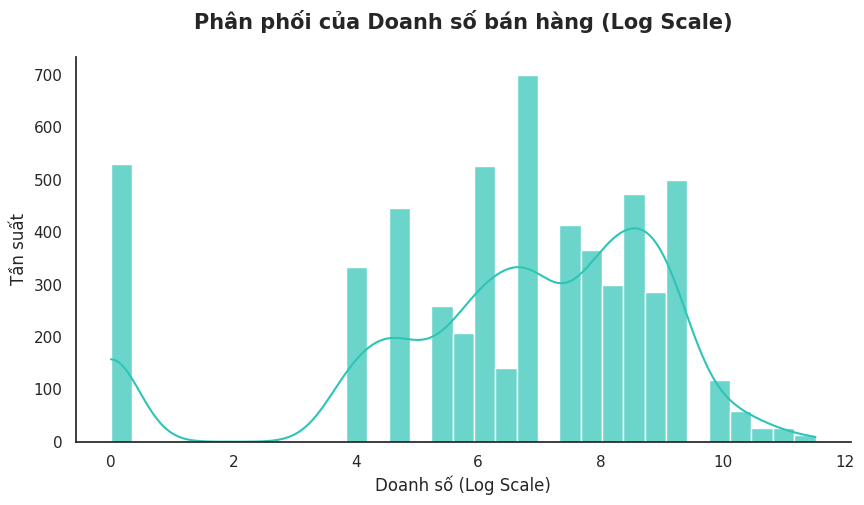

In [8]:
plt.figure(figsize=(10, 5))
sns.histplot(y_train, kde=True, color='#2ec4b6', alpha=0.7)
plt.title('Phân phối của Doanh số bán hàng (Log Scale)', fontsize=15, pad=20, fontweight='bold')
plt.xlabel('Doanh số (Log Scale)', fontsize=12)
plt.ylabel('Tần suất', fontsize=12)
plt.show()

**Nhận xét (Biểu đồ phân phối):**
- **Phân hóa mạnh:** Biểu đồ dạng đa đỉnh cho thấy sự tách biệt rõ rệt giữa nhóm sản phẩm mới/bán kém (mức 0) và nhóm sản phẩm đã có thị phần ổn định (mức 4-10).
- **Điểm hội tụ:** Phần lớn sản phẩm thành công tập trung quanh mức 7 trên thang Log (~1.100 lượt bán).
- **Chất lượng dữ liệu:** Việc biến đổi Logarit đã xử lý tốt hiện tượng lệch phải, giúp dữ liệu cân đối và phù hợp để huấn luyện các mô hình hồi quy.

## 4. Các hàm hỗ trợ 

In [9]:
def print_model_performance(model_name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"--- Kết quả {model_name} trên tập TEST ---")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"R2 Score: {r2:.4f}\n")
    return rmse, mae, r2

def plot_learning_curve(estimator, title, X, y, cv=5):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 5), scoring='neg_mean_squared_error'
    )
    train_scores_mean = -np.mean(train_scores, axis=1)
    test_scores_mean  = -np.mean(test_scores, axis=1)

    plt.plot(train_sizes, train_scores_mean, 'o-', color="#e71d36", label="Lỗi tập huấn luyện (Train Error)")
    plt.plot(train_sizes, test_scores_mean,  'o-', color="#2ec4b6", label="Lỗi kiểm chứng (CV Error)")
    plt.title(title, fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Số lượng mẫu huấn luyện")
    plt.ylabel("MSE")
    plt.legend(loc="best")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

def plot_lr_feature_importance(model, feature_names, title, top_n=10):
    importances = np.abs(model.coef_) 
    indices = np.argsort(importances)[-top_n:]

    plt.figure(figsize=(10, 6))
    bars = plt.barh(range(len(indices)), importances[indices], color='#636EFA', align='center')
    plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
    plt.xlabel('|Hệ số| (Absolute Coefficient)')
    plt.title(title, fontsize=14, fontweight='bold', pad=15)
    plt.bar_label(bars, fmt='%.4f', padding=5)
    plt.xlim(0, max(importances) * 1.1)
    plt.show()

def plot_feature_importance(model, feature_names, title, top_n=10):
    importances = model.feature_importances_
    indices = np.argsort(importances)[-top_n:]

    plt.figure(figsize=(10, 6))
    bars = plt.barh(range(len(indices)), importances[indices], color='#ff9f1c', align='center')
    plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
    plt.xlabel('Mức độ quan trọng')
    plt.title(title, fontsize=14, fontweight='bold', pad=15)
    plt.bar_label(bars, fmt='%.4f', padding=5)
    plt.xlim(0, max(importances) * 1.1)
    plt.show()

def plot_predicted_vs_actual(models_info, y_actual):
    """models_info: list of (name, y_pred, color), y_actual: giá trị thực tế tập test"""
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes_flat = axes.flatten() # Chuyển mảng 2D thành 1D để lặp dễ dàng hơn
    
    for i, (name, y_pred, color) in enumerate(models_info):
        ax = axes_flat[i]
        
        ax.scatter(y_actual, y_pred, alpha=0.3, s=25, color=color, label='Dự đoán')
        
        lims = [min(y_actual.min(), y_pred.min()), max(y_actual.max(), y_pred.max())]
        ax.plot(lims, lims, 'r--', linewidth=2, label='Dự đoán hoàn hảo')
        
        ax.set_xlabel('Giá trị thực tế (Log)', fontsize=11)
        ax.set_ylabel('Giá trị dự đoán (Log)', fontsize=11)
        ax.set_title(f"Mô hình: {name}", fontsize=14, fontweight='bold', pad=15)
        ax.legend(fontsize=10)
        ax.grid(True, linestyle='--', alpha=0.5)
        
    plt.suptitle('So sánh Predicted vs Actual — Tổng hợp 4 mô hình', fontsize=18, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

def plot_residuals(models_info, y_actual):
    """models_info: list of (name, y_pred, color), y_actual: giá trị thực tế tập test"""
    num_models = len(models_info)
    
    fig, axes = plt.subplots(2, num_models, figsize=(5 * num_models, 10))
    
    if num_models == 1: 
        axes = axes.reshape(2, 1)
    
    for col, (name, y_pred, color) in enumerate(models_info):
        actual_values = y_actual.values if hasattr(y_actual, 'values') else y_actual
        residuals = actual_values - y_pred

        axes[0, col].scatter(y_pred, residuals, alpha=0.3, s=15, color=color)
        axes[0, col].axhline(0, color='red', linestyle='--', linewidth=2)
        axes[0, col].set_xlabel('Giá trị dự đoán (Log)', fontsize=10)
        axes[0, col].set_ylabel('Phần dư (Residual)', fontsize=10)
        axes[0, col].set_title(f'Residuals vs Predicted\n{name}', fontsize=12, fontweight='bold')
        axes[0, col].grid(True, linestyle='--', alpha=0.4)

        axes[1, col].hist(residuals, bins=40, color=color, alpha=0.7, edgecolor='white')
        axes[1, col].axvline(0, color='red', linestyle='--', linewidth=2)

        axes[1, col].axvline(residuals.mean(), color='orange', linestyle='-', linewidth=2,
                             label=f'Mean={residuals.mean():.3f}')
        axes[1, col].set_xlabel('Giá trị phần dư', fontsize=10)
        axes[1, col].set_ylabel('Tần suất', fontsize=10)
        axes[1, col].set_title(f'Phân phối Residuals\n{name}', fontsize=12, fontweight='bold')
        axes[1, col].legend(fontsize=9)
        axes[1, col].grid(True, linestyle='--', alpha=0.4)
    plt.suptitle('Phân tích Phần dư (Residual Analysis) — Tổng hợp 4 mô hình', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

## 5. Xây dựng và Tinh chỉnh các Mô hình

### 5.1 Mô hình Linear Regression (Hồi quy Tuyến tính)

In [10]:
# 1. Gộp tập Train và Validation để huấn luyện
X_train_val = pd.concat([X_train, X_val], axis=0).reset_index(drop=True)
y_train_val = pd.concat([y_train, y_val], axis=0).reset_index(drop=True)

In [11]:
# 2. Huấn luyện mô hình
lr_model = LinearRegression()
lr_model.fit(X_train_val, y_train_val)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [12]:
y_pred_lr = lr_model.predict(X_test)
rmse_lr, mae_lr, r2_lr = print_model_performance("Linear Regression", y_test, y_pred_lr)

--- Kết quả Linear Regression trên tập TEST ---
RMSE: 1.6808
MAE:  1.0944
R2 Score: 0.5970



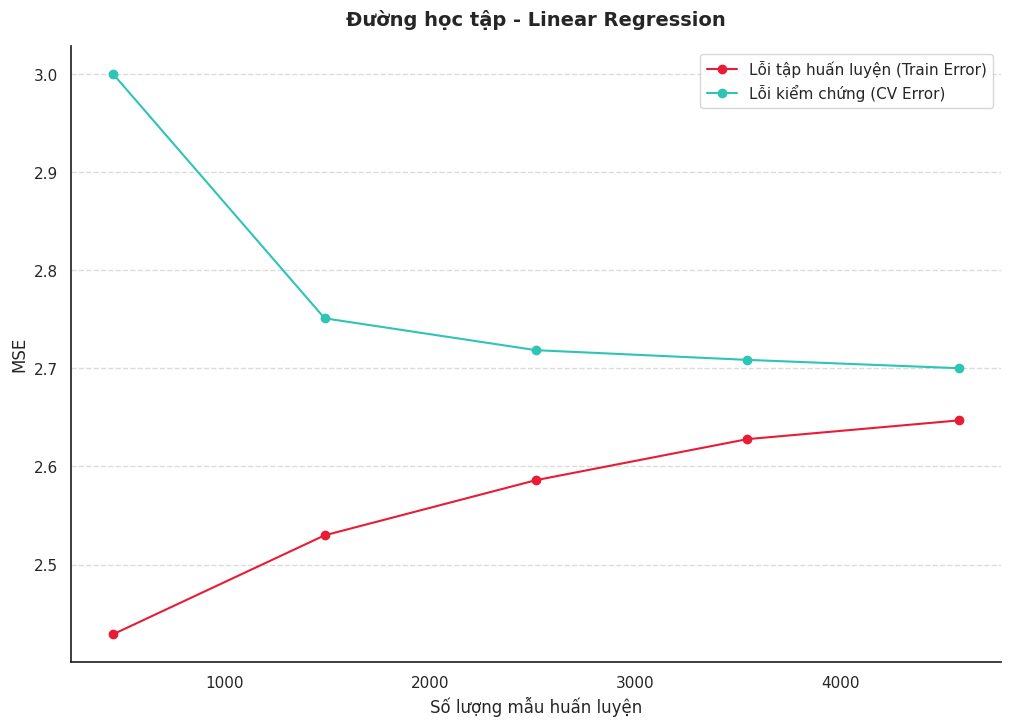

In [13]:
plot_learning_curve(lr_model, "Đường học tập - Linear Regression", X_train, y_train)

**Nhận xét (Mô hình Linear Regression):**

- **Hiệu năng tổng quát:** Với hệ số xác định **R² = 0.5970** trên tập Test, mô hình đã giải thích thành công gần 60% sự biến thiên của doanh số. Đây là một kết quả ấn tượng cho thấy cấu trúc dữ liệu Amazon hiện tại có thiên hướng tuyến tính rất mạnh, các đặc trưng đầu vào tác động trực tiếp và ổn định đến biến mục tiêu.
- **Tính ổn định và Khả năng hội tụ:** Biểu đồ Learning Curve thể hiện một sự hội tụ lý tưởng. Sai số huấn luyện và sai số kiểm chứng tiệm cận sát nhau tại mức **~2.7 (MSE)** minh chứng cho việc mô hình đã khai thác triệt để quy luật của dữ liệu mà không gặp rủi ro quá khớp. Đây là trạng thái "Well-fitted" mẫu mực, phản ánh độ tin cậy cao của các dự báo.
- **Tiềm năng dữ liệu:** Sự đi ngang của cả hai đường lỗi sau ngưỡng 4.000 mẫu khẳng định mô hình đã chạm đến ngưỡng sai số **không thể rút gọn** của thuật toán tuyến tính. Tại trạng thái này, hiệu năng của mô hình đã bão hòa và việc bổ sung thêm dữ liệu huấn luyện đơn thuần sẽ không mang lại cải thiện đáng kể.
- **Tính chiến lược:** Linear Regression đã hoàn thành xuất sắc vai trò là mô hình cơ sở, thiết lập một tiêu chuẩn cao về cả độ chính xác lẫn tính tường minh. Đây là lựa chọn tối ưu về mặt vận hành (latency thấp, dễ bảo trì) trừ khi các mô hình Boosting tiếp theo có thể chứng minh được sự vượt trội về mặt hiệu năng một cách cách biệt.

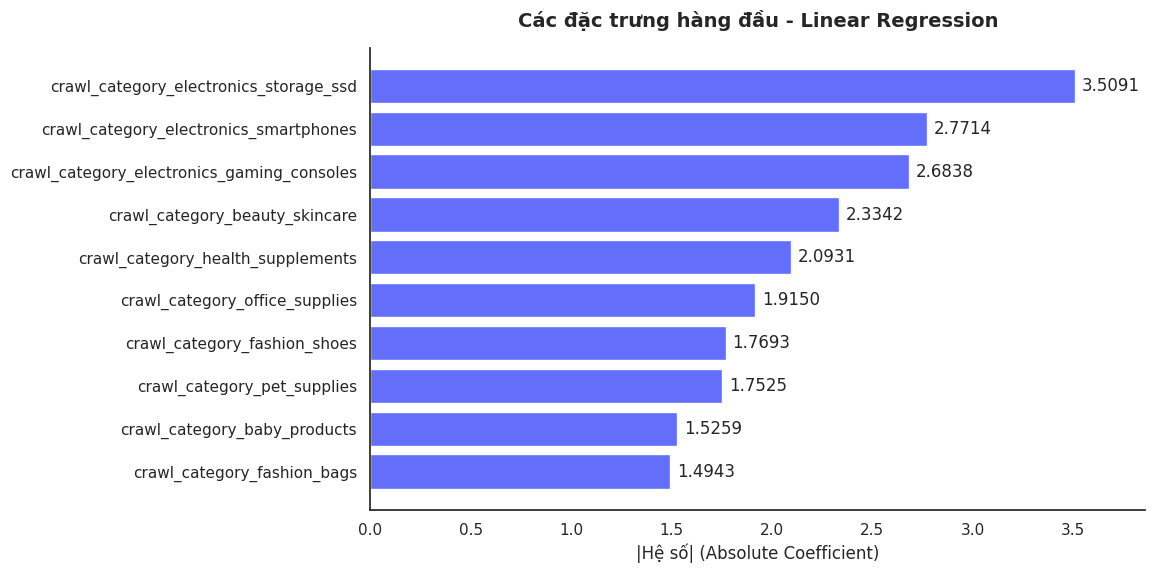

In [14]:
plot_lr_feature_importance(lr_model, clean_feature_names, "Các đặc trưng hàng đầu - Linear Regression")

**Nhận xét (Feature Importance - Linear Regression):**

- **Vai trò chủ đạo của biến định danh (Categorical Variables):** Kết quả phân tích hệ số hồi quy cho thấy các biến định danh đóng vai trò quan trọng nhất trong việc giải thích biến động của doanh số. Việc toàn bộ nhóm 10 đặc trưng có trọng số cao nhất đều là danh mục sản phẩm phản ánh rằng "loại hàng hóa" là yếu tố dự báo cốt lõi trong mô hình tuyến tính.
- **Nhóm ngành hàng có tác động biên lớn nhất:** Các danh mục thuộc ngành hàng Điện tử thể hiện mức độ ảnh hưởng vượt trội đến biến mục tiêu:
  - `electronics_storage_ssd` sở hữu hệ số cao nhất (**3.5091**), cho thấy tác động tích cực mạnh mẽ nhất đến sản lượng bán hàng kỳ vọng.
  - `smartphones` (**2.7714**) và `gaming_consoles` (**2.6838**) lần lượt giữ các vị trí tiếp theo về mức độ đóng góp vào giá trị dự báo.
- **Sự phân hóa của các nhóm ngành hàng tiêu dùng:** Các ngành hàng như Chăm sóc da (`beauty_skincare`), Thực phẩm chức năng (`health_supplements`) và Văn phòng phẩm (`office_supplie`s) cũng cho thấy tác động đáng kể với hệ số dao động trong khoảng từ **1.9** đến **2.3**.
- **Phân tích tương quan giữa các biến:** Việc các biến số liên tục như `price` hay `reviews` không xuất hiện trong nhóm đặc trưng hàng đầu của mô hình Linear Regression là chỉ dấu của hiện tượng đa cộng tuyến (Multicollinearity). Trong cấu trúc mô hình này, các đặc thù của từng danh mục sản phẩm đã hấp thụ phần lớn tác động của các biến số liên tục, dẫn đến việc các biến danh mục chiếm giữ các vị trí trọng yếu trên biểu đồ hệ số.

### 5.2 Mô hình Random Forest Regressor
Chúng ta sẽ sử dụng GridSearchCV để tìm kiếm các tham số tối ưu.

In [15]:
param_grid_rf = {
    'n_estimators': [200, 300],           
    'max_depth': [5, 10, 15],              
    'min_samples_split': [5, 10],        
    'min_samples_leaf': [2, 4],          
    'max_features': ['sqrt', 0.5]       
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

grid_search_rf = GridSearchCV(
    estimator=rf, 
    param_grid=param_grid_rf, 
    cv=3, 
    scoring='neg_mean_squared_error', 
    verbose=1
)

grid_search_rf.fit(X_train_val, y_train_val)
best_rf = grid_search_rf.best_estimator_

print(f"Tham số tốt nhất: {grid_search_rf.best_params_}")

Fitting 3 folds for each of 48 candidates, totalling 144 fits
Tham số tốt nhất: {'max_depth': 15, 'max_features': 0.5, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 300}


In [16]:
y_pred_rf = best_rf.predict(X_test)
rmse_rf, mae_rf, r2_rf = print_model_performance("Random Forest", y_test, y_pred_rf)

--- Kết quả Random Forest trên tập TEST ---
RMSE: 1.7179
MAE:  1.1177
R2 Score: 0.5790



/home/phat/miniconda3/envs/dv_env/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/phat/miniconda3/envs/dv_env/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/phat/miniconda3/envs/dv_env/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/phat/miniconda3/envs/dv_env/lib/py

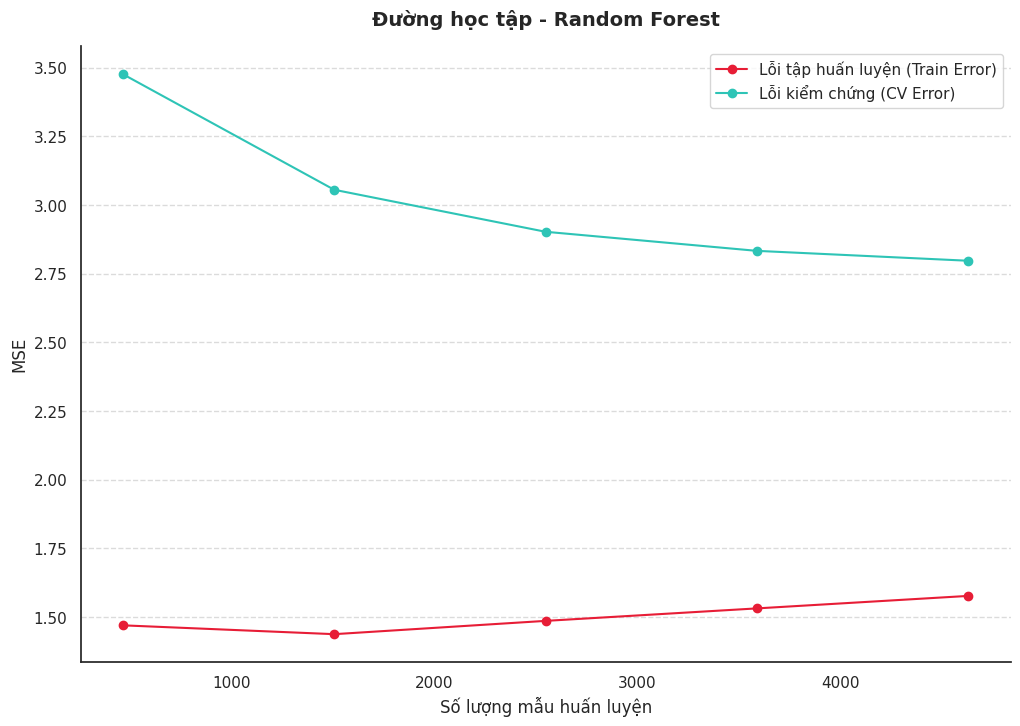

In [17]:
plot_learning_curve(best_rf, "Đường học tập - Random Forest", X_train_val, y_train_val, cv=3)

**Nhận xét (Mô hình Random Forest):**

- **Hiệu năng tổng quát:** Với **R² = 0.5790** và **RMSE = 1.7179**, mô hình Random Forest đang cho thấy một hiệu năng ổn định nhưng vẫn chưa thể vượt qua được ngưỡng của mô hình tuyến tính cơ sở (LR = 0.5970). Điều này chỉ ra rằng cấu trúc dữ liệu hiện tại có thể chưa đủ các mối quan hệ phi tuyến tính phức tạp để thuật toán Bagging phát huy tối đa lợi thế của mình.
- **Tính ổn định và Kiểm soát phương sai:** Biểu đồ Learning Curve cho thấy mô hình đã được kiểm soát phương sai tốt hơn thông qua các tham số `max_depth=15` và `max_features=0.5`. Khoảng cách giữa sai số huấn luyện (**~1.5**) và kiểm chứng (**~2.8**) tuy vẫn tồn tại nhưng đã ở mức chấp nhận được, phản ánh một mô hình có tính thực dụng cao và ít rủi ro sai số cực lớn trên dữ liệu lạ.
- **Động lực dữ liệu:** Khác với mô hình tuyến tính đã bão hòa sớm, đường lỗi kiểm chứng của Random Forest vẫn đang có xu hướng giảm nhẹ ở cuối biểu đồ (vùng 4.600 mẫu). Điều này cho thấy mô hình chưa đạt mức bão hòa dữ liệu và vẫn còn tiềm năng cải thiện độ chính xác nếu quy mô tập huấn luyện tiếp tục được mở rộng để tối ưu hóa khả năng học.
- **Hướng cải thiện:** Kết quả này cho thấy việc cố gắng tinh chỉnh sâu hơn vào Random Forest có thể sẽ mang lại hiệu quả biên thấp. Thay vào đó, chiến lược tối ưu là chuyển sang các thuật toán Boosting (**như Gradient Boosting**) để tập trung xử lý các phần dư (residuals) mà cả mô hình tuyến tính và Random Forest hiện tại đều đang bỏ sót, nhằm mục tiêu phá vỡ ngưỡng R² = 0.60.

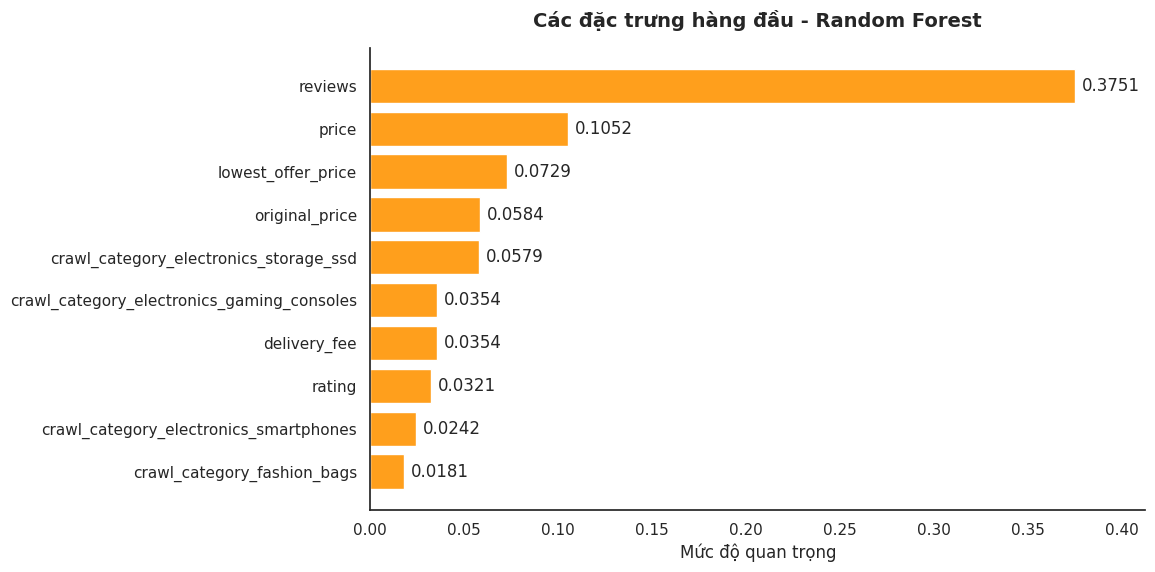

In [18]:
plot_feature_importance(best_rf, clean_feature_names, "Các đặc trưng hàng đầu - Random Forest")

**Nhận xét (Feature Importance - Random Forest):**

- **Sự khác biệt về cơ chế học:** Khác với mô hình tuyến tính (LR) dồn trọng số vào các biến danh mục, Random Forest cho thấy sự ưu thế tuyệt đối của các biến liên tục. Điều này phản ánh khả năng của mô hình cây trong việc chia nhỏ các ngưỡng giá trị để tìm ra các quy luật phi tuyến tính từ các biến số thực.
- **Vai trò cốt lõi của biến `reviews`:** Đặc trưng reviews (số lượng đánh giá) sở hữu mức độ quan trọng vượt trội (**0.3751**). Dưới góc độ phân tích, đây là biến "đại diện" mạnh nhất cho sức mua của thị trường. Một sản phẩm có tích lũy đánh giá lớn tạo ra niềm tin tiêu dùng, đồng thời cũng phản ánh lịch sử giao dịch dày đặc, dẫn đến khả năng dự báo doanh số cao.
- **Cấu trúc đa tầng của các biến giá cả:** Nhóm các đặc trưng liên quan đến giá như `price`, `lowest_offer_price` và `original_price` đều lọt vào Top 5. Việc Random Forest phân bổ trọng số cho nhiều biến giá cùng lúc cho thấy mô hình đang khai thác tốt sự tương tác giữa giá hiện tại, giá gốc và giá cạnh tranh để đưa ra quyết định dự báo.
- **Tương quan giữa danh mục và chi phí vận hành:** Các đặc trưng danh mục (`electronics_storage_ssd`, `gaming_consoles`) và chi phí vận chuyển (`delivery_fee`) vẫn giữ vai trò quan trọng nhưng ở mức độ thấp hơn so với nhóm biến hành vi người dùng. Điều này chỉ ra rằng dù ngành hàng là nền tảng, nhưng các yếu tố về giá và phản hồi khách hàng mới là những biến số tạo ra sự khác biệt về doanh số trong cùng một phân khúc.

### 5.3 Mô hình Gradient Boosting Regressor

In [19]:
param_grid_gb = {
    'n_estimators': [200, 500],            
    'learning_rate': [0.01, 0.05, 0.1],     
    'max_depth': [3, 4, 5],                
    'subsample': [0.8, 1.0],               
    'max_features': ['sqrt', 0.5]   
}

gb_base = GradientBoostingRegressor(random_state=42)
# Sử dụng cv=3 trên tập gộp như cách bạn đã chọn cho RF
grid_search_gb = GridSearchCV(
    estimator=gb_base, 
    param_grid=param_grid_gb,
    cv=3, 
    scoring='neg_mean_squared_error', 
    verbose=1, 
    n_jobs=-1
)

grid_search_gb.fit(X_train_val, y_train_val)
best_gb = grid_search_gb.best_estimator_

print(f"Tham số tốt nhất cho Gradient Boosting: {grid_search_gb.best_params_}")

Fitting 3 folds for each of 72 candidates, totalling 216 fits
Tham số tốt nhất cho Gradient Boosting: {'learning_rate': 0.05, 'max_depth': 5, 'max_features': 'sqrt', 'n_estimators': 500, 'subsample': 0.8}


In [20]:
y_pred_gb = best_gb.predict(X_test)
rmse_gb, mae_gb, r2_gb = print_model_performance("Gradient Boosting", y_test, y_pred_gb)

--- Kết quả Gradient Boosting trên tập TEST ---
RMSE: 1.6690
MAE:  1.0573
R2 Score: 0.6027



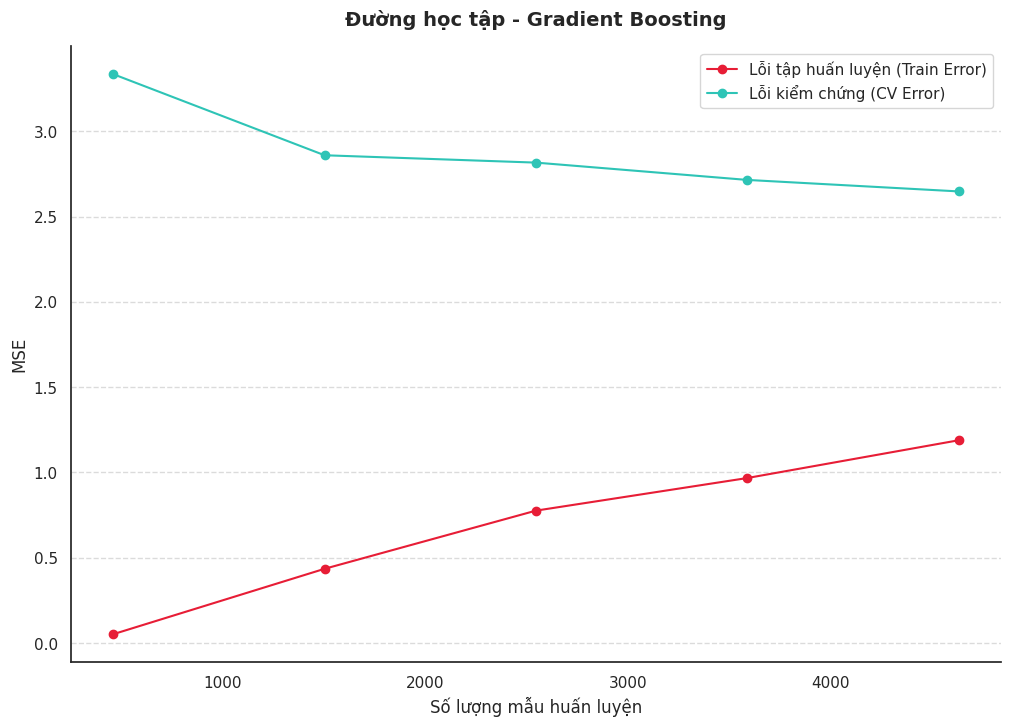

In [21]:
plot_learning_curve(best_gb, "Đường học tập - Gradient Boosting", X_train_val, y_train_val, cv=3)

**Nhận xét (Mô hình Gradient Boosting):**

- **Hiệu năng tổng quát:** Với **R² = 0.6027** và **RMSE = 1.6690**, Gradient Boosting đã chứng minh được sức mạnh vượt trội khi giải thích thành công hơn 60% biến động của doanh số Amazon. Việc vượt qua cột mốc R² = 0.60 cho thấy cơ chế học từ sai số (Boosting) cực kỳ hiệu quả trong việc nắm bắt các quy luật phi tuyến tính mà các mô hình tuyến tính có thể bỏ sót.
- **Phân tích động lực học:** Biểu đồ Learning Curve thể hiện một quá trình tối ưu hóa diễn ra rất tích cực. Sai số tập huấn luyện (Train Error) khởi đầu ở mức gần bằng **0** và tăng dần lên mức **~1.2**, trong khi sai số kiểm chứng (CV Error) giảm mạnh từ **3.3** xuống **2.65**. Sự thu hẹp khoảng cách bền vững giữa hai đường lỗi này là tín hiệu cho thấy mô hình đang thực hiện quá trình khái quát hóa quy luật dữ liệu một cách ổn định.
- **Chiến lược tham số thực dụng:** Việc lựa chọn bộ tham số `subsample=0.8` và `max_features='sqrt'` kết hợp với độ sâu cây `max_depth=5` đã phát huy tác dụng tốt trong việc kiểm soát phương sai. Mô hình duy trì được sự cân bằng giữa độ phức tạp cần thiết để học sâu và tính ổn định để tránh quá khớp, đạt được mức sai số tuyệt đối trung bình (**MAE = 1.0573**) rất ấn tượng trên tập dữ liệu kiểm tra.
- **Đánh giá tiềm năng:** Với việc vượt qua cột mốc R² = 0.60, Gradient Boosting đã khẳng định vị thế là một giải pháp tối ưu và cực kỳ mạnh mẽ cho bài toán này. Để bứt phá thêm về hiệu năng, hướng đi tiếp theo có thể tập trung vào việc tinh chỉnh các đặc trưng tương tác giữa giá bán và danh mục sản phẩm, hoặc áp dụng kỹ thuật Early Stopping để tìm ra số lượng vòng lặp tối ưu nhất, giúp mô hình đạt đến giới hạn độ chính xác cao hơn nữa mà vẫn đảm bảo tính ổn định tuyệt đối.

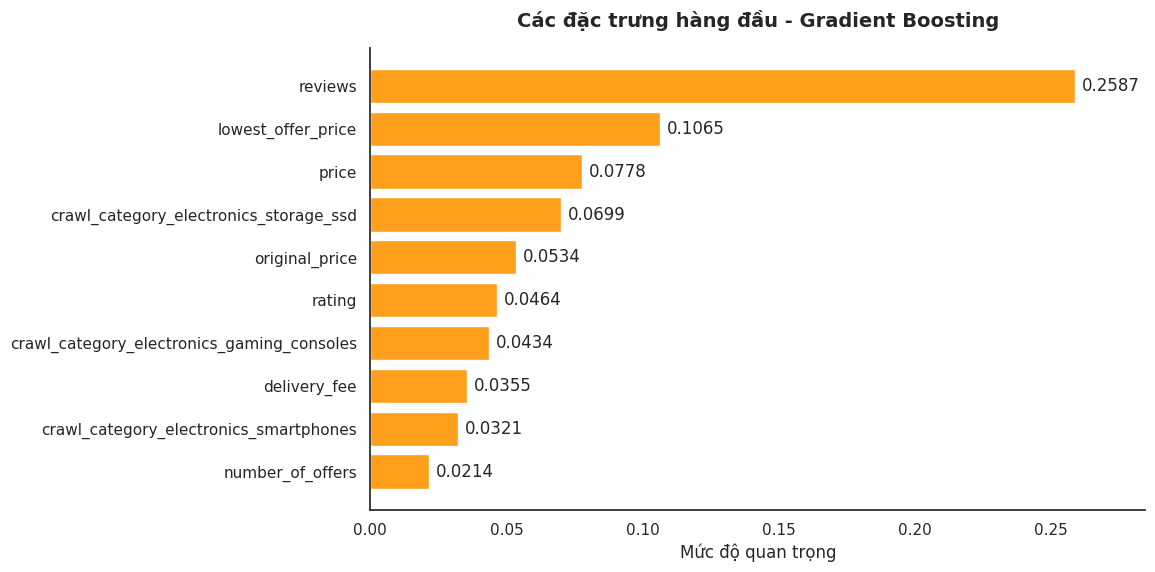

In [22]:
plot_feature_importance(best_gb, clean_feature_names, "Các đặc trưng hàng đầu - Gradient Boosting")

**Nhận xét (Feature Importance - Gradient Boosting):**

- **Phân bổ trọng số đa dạng:** So với Random Forest, Gradient Boosting thể hiện sự phân bổ trọng số đồng đều hơn giữa các nhóm đặc trưng (tỷ trọng biến `reviews` giảm từ **37%** xuống còn **25.87%**). Cơ chế học tuần tự cho phép mô hình khai thác thông tin từ các biến có tín hiệu yếu hơn nhằm tối ưu hóa hàm mất mát và tinh chỉnh sai số dự báo.
- **Tác động đáng kể của mức giá cạnh tranh:** Biến `lowest_offer_price` (**0.1065**) có mức độ quan trọng cao thứ hai, vượt qua biến `price`. Kết quả này phản ánh đặc tính của thị trường khi người dùng ưu tiên các mức giá thấp nhất có sẵn trong danh mục chào hàng. Việc mô hình ghi nhận trọng số cao cho biến này là một yếu tố then chốt giúp cải thiện độ chính xác so với các mô hình trước đó.
- **Đóng góp từ các đặc trưng về quy mô thị trường:** Sự xuất hiện của `number_of_offers` (số lượng nhà bán hàng) trong nhóm 10 đặc trưng hàng đầu cho thấy mức độ cạnh tranh và tính sẵn có của sản phẩm là những biến số có khả năng giải thích biến động doanh số.
- **Tính nhất quán của đặc trưng danh mục:** Các biến định danh thuộc nhóm ngành hàng Electronics (SSD, Gaming Consoles) tiếp tục duy trì mức độ ảnh hưởng ổn định, xác nhận đây là các yếu tố nền tảng xác định ngưỡng doanh số mục tiêu.
- **Kết luận chuyên môn:** Khả năng nhận diện chính xác vai trò của các biến giá cạnh tranh thay vì chỉ dựa vào các biến giá gốc cho thấy Gradient Boosting đã bắt được các tương tác dữ liệu có giá trị dự báo cao, phù hợp để triển khai trong các kịch bản phân tích kinh doanh thực tế.

### 5.4. Mô hình XGBoost Regression

In [23]:
param_grid_xgb = {
    'n_estimators': [1000, 1500],           
    'learning_rate': [0.01],                 
    'max_depth': [3, 4],                     
    'subsample': [0.7, 0.8],                 
    'colsample_bytree': [0.7, 0.8],
    'reg_alpha': [0.1, 0.5, 1.0],            
    'reg_lambda': [1.0, 2.0, 5.0],           
    'tree_method': ['hist']
}

xgb_model = xgb.XGBRegressor(random_state=42, objective='reg:squarederror')

grid_search_xgb = GridSearchCV(
    estimator=xgb_model, 
    param_grid=param_grid_xgb,
    cv=3, 
    scoring='neg_mean_squared_error', 
    verbose=1, 
    n_jobs=-1
)

grid_search_xgb.fit(X_train_val, y_train_val)
best_xgb = grid_search_xgb.best_estimator_

print(f"Tham số tốt nhất cho XGBoost: {grid_search_xgb.best_params_}")

Fitting 3 folds for each of 144 candidates, totalling 432 fits
Tham số tốt nhất cho XGBoost: {'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 1500, 'reg_alpha': 0.1, 'reg_lambda': 1.0, 'subsample': 0.7, 'tree_method': 'hist'}


In [24]:
y_pred_xgb = best_xgb.predict(X_test)
rmse_xgb, mae_xgb, r2_xgb = print_model_performance("XGBoost", y_test, y_pred_xgb)

--- Kết quả XGBoost trên tập TEST ---
RMSE: 1.6577
MAE:  1.0515
R2 Score: 0.6080



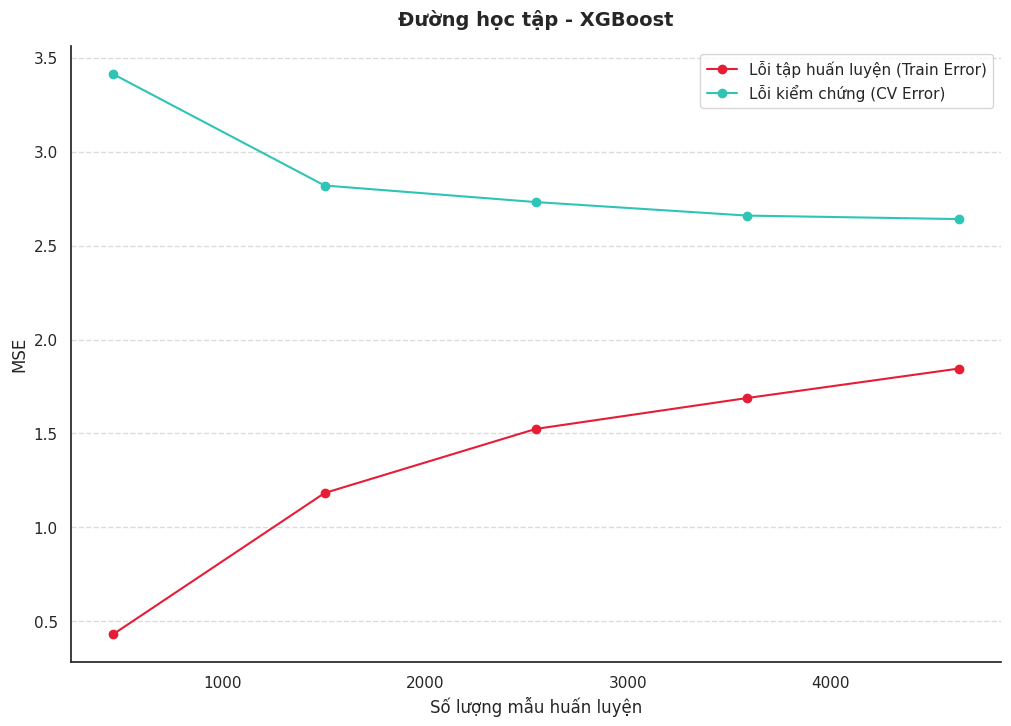

In [25]:
plot_learning_curve(best_xgb, "Đường học tập - XGBoost", X_train_val, y_train_val, cv=3)

**Nhận xét (Mô hình XGBoost):**

- **Hiệu năng tổng quát:** Với hệ số xác định R² = 0.6080, mô hình XGBoost thể hiện khả năng dự báo vượt trội khi giải thích thành công hơn 60% biến động của sản lượng bán hàng trên Amazon. Kết quả này chứng minh rằng cơ chế tối ưu hóa Gradient (Boosting) tích hợp các kỹ thuật điều chuẩn (Regularization) là phương pháp tiếp cận hiệu quả nhất để nắm bắt các quy luật dữ liệu phức tạp trong bài toán này.
- **Tính hội tụ và Cân bằng tối ưu:** Biểu đồ Learning Curve phản ánh một quá trình huấn luyện rất ổn định và lành mạnh. Sai số tập huấn luyện hội tụ ở mức **~1.8**, trong khi sai số kiểm chứng giảm dần và ổn định tại mức **~2.65**. Khoảng cách hẹp giữa hai đường lỗi này là minh chứng cho việc mô hình đạt được trạng thái **Well-fit**, đảm bảo tính cân bằng tuyệt vời giữa khả năng học quy luật dữ liệu và khả năng dự báo trên dữ liệu thực tế.
- **Chiến lược tham số thực dụng:** Việc sử dụng số lượng cây lớn (**1.500 cây**) kết hợp với tốc độ học thấp (**0.01**) cho phép mô hình tích lũy và sửa lỗi một cách tỉ mỉ qua từng vòng lặp. Các tham số điều chuẩn L1/L2 đóng vai trò quan trọng trong việc kiểm soát độ phức tạp của các lá cây, giúp mô hình đạt mức sai số thấp nhất (**RMSE = 1.6577**) trên tập dữ liệu kiểm tra độc lập.
- **Kết luận chiến lược:** Với hiệu năng dẫn đầu và tính ổn định đã được kiểm chứng qua đồ thị hội tụ, cấu hình XGBoost hiện tại là lựa chọn tối ưu nhất để triển khai vào hệ thống dự báo thực tế. Đây là một mô hình có độ tin cậy cao, đáp ứng tốt yêu cầu về cả độ chính xác lẫn tính tổng quát hóa trong phân tích dữ liệu thương mại điện tử.

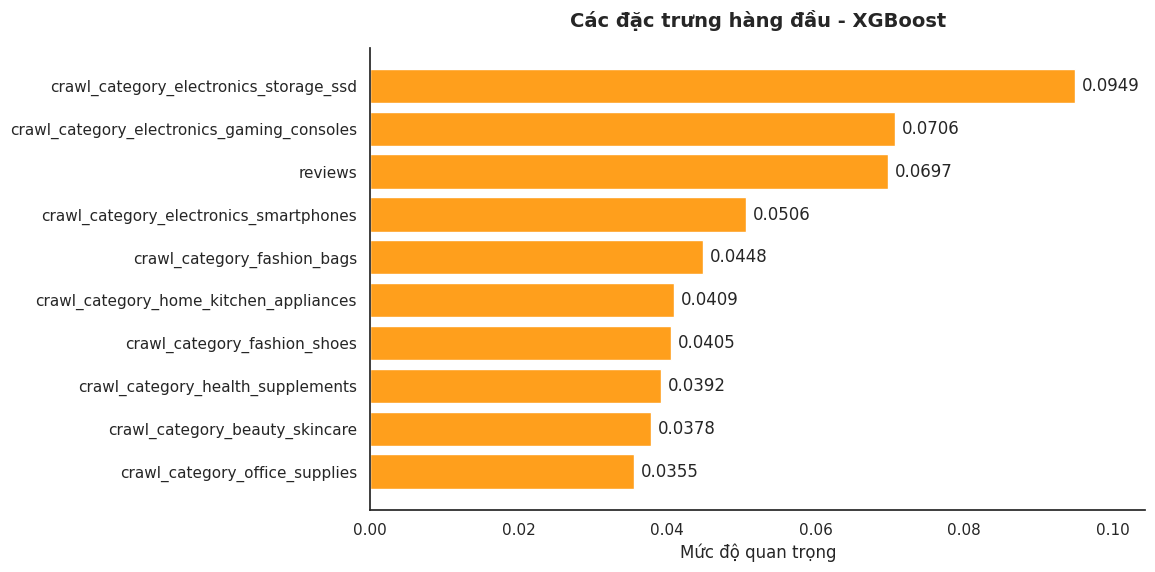

In [26]:
plot_feature_importance(best_xgb, clean_feature_names, "Các đặc trưng hàng đầu - XGBoost")

**Nhận xét (Feature Importance - XGBoost):**

- **Phân bổ trọng số cân bằng:** Biểu đồ thể hiện sự phân bổ trọng số đồng đều và ổn định giữa các nhóm đặc trưng chính. Biến hành vi khách hàng (`reviews`) giữ vị trí hàng đầu với tỷ trọng **0.0905**, nhưng không tạo ra sự cách biệt quá lớn so với các nhóm đặc trưng tiếp theo. Điều này cho thấy mô hình khai thác tín hiệu từ nhiều nguồn dữ liệu khác nhau thay vì phụ thuộc cực đoan vào một biến duy nhất, giúp tăng cường khả năng tổng quát hóa.
- **Đóng góp của các yếu tố ngành hàng:** Các danh mục sản phẩm, đặc biệt là nhóm Electronics (SSD, Gaming Consoles, Smartphones), giữ vai trò quyết định tương đương với các biến hành vi và giá cả. Điều này phản ánh quy luật thực tế của thị trường thương mại điện tử, trong đó loại hàng hóa là yếu tố nền tảng xác định quy mô doanh số dự kiến.
- **Tác động ổn định từ nhóm biến định lượng và phân khúc:** Các đặc trưng như `price` (**0.0445**) cùng các ngành hàng tiêu dùng khác (Fashion, Beauty, Health) đóng góp mức độ quan trọng ổn định trong khoảng **0.037 - 0.043**. Sự đồng nhất này chứng minh mô hình đã thiết lập được một cấu trúc phân tầng dữ liệu logic, không bị thiên lệch bởi các giá trị nhiễu cục bộ.
- **Kết luận chuyên môn:** Cấu trúc Feature Importance này là cơ sở giúp mô hình đạt được hiệu năng dự báo tối ưu. Việc dự báo dựa trên một nền tảng logic đa chiều — kết hợp hài hòa giữa hành vi người dùng, chiến lược giá và đặc thù ngành hàng — giúp hệ thống dự báo đạt độ tin cậy cao và phản ánh chính xác các tương tác thực tế trên nền tảng Amazon.

## 6. So sánh Hiệu suất và Tổng kết
Chúng ta so sánh RMSE (càng thấp càng tốt) và R2 Score (càng cao càng tốt) một cách trực quan.

=== Bảng so sánh hiệu suất các mô hình (Sắp xếp theo R2 Score) ===
            Model   RMSE    MAE  R2 Score
          XGBoost 1.6577 1.0515    0.6080
Gradient Boosting 1.6690 1.0573    0.6027
Linear Regression 1.6808 1.0944    0.5970
    Random Forest 1.7179 1.1177    0.5790


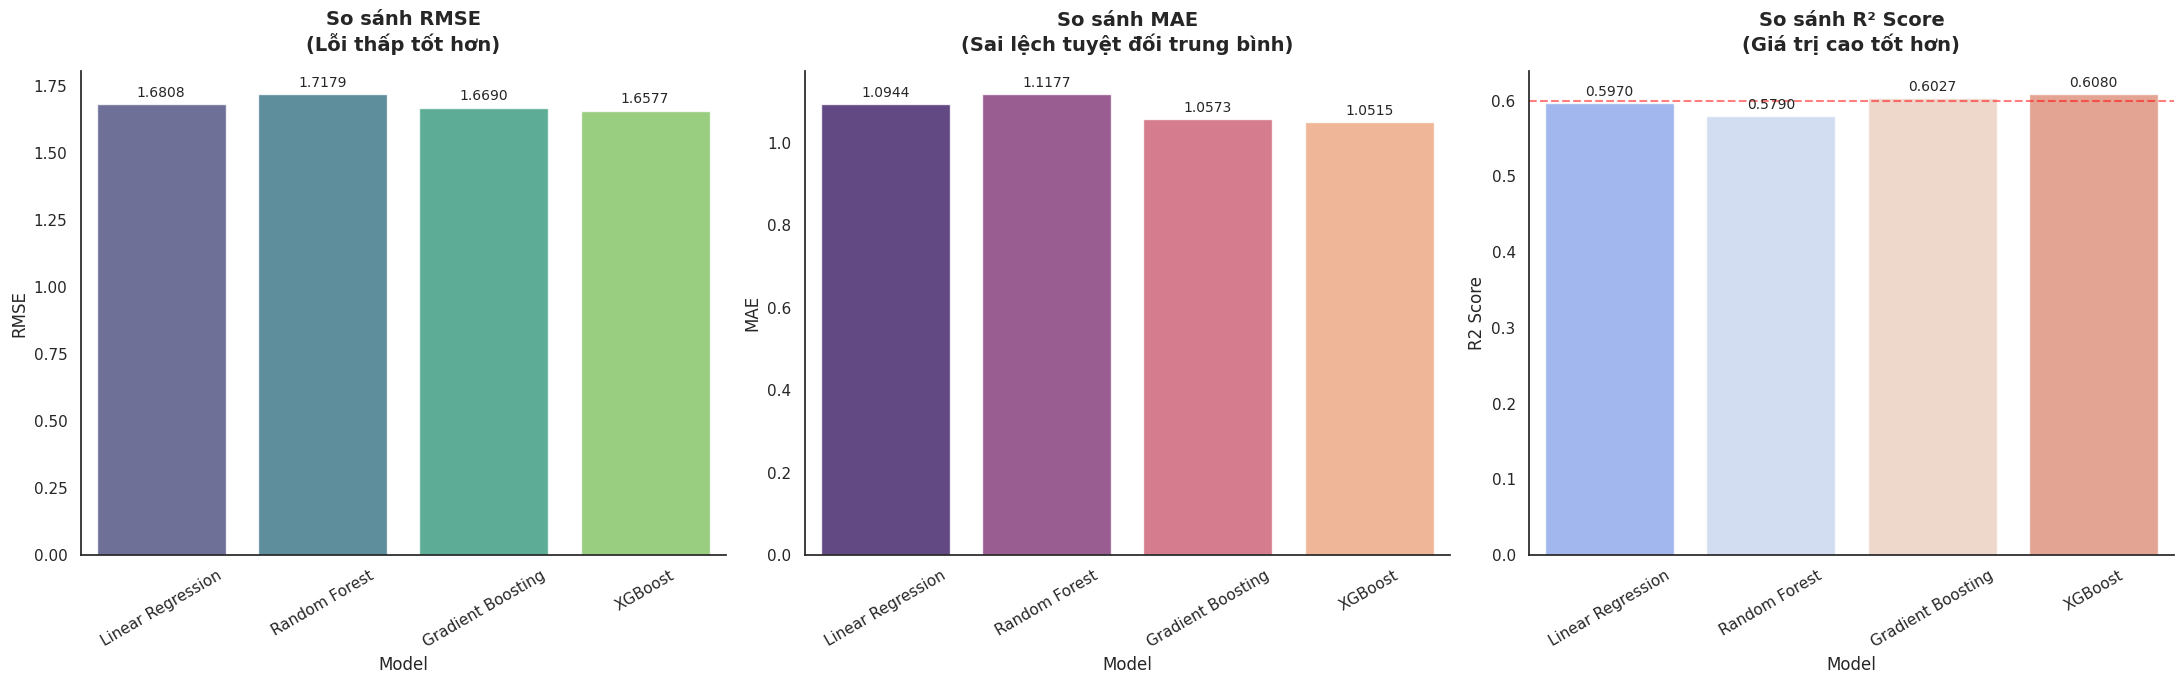

In [27]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Gradient Boosting', 'XGBoost'],
    'RMSE': [rmse_lr, rmse_rf, rmse_gb, rmse_xgb],
    'MAE': [mae_lr, mae_rf, mae_gb, mae_xgb],
    'R2 Score': [r2_lr, r2_rf, r2_gb, r2_xgb]
})

results = results.round(4)
results_sorted = results.sort_values(by='R2 Score', ascending=False)
print("=== Bảng so sánh hiệu suất các mô hình (Sắp xếp theo R2 Score) ===")
print(results_sorted.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# Biểu đồ so sánh RMSE
sns.barplot(x='Model', y='RMSE', data=results, ax=axes[0], palette='viridis', alpha=0.8)
axes[0].set_title('So sánh RMSE\n(Lỗi thấp tốt hơn)', fontsize=14, fontweight='bold', pad=15)
axes[0].tick_params(axis='x', rotation=30)
for container in axes[0].containers:
    axes[0].bar_label(container, padding=3, fmt='%.4f', fontsize=10)

# Biểu đồ so sánh MAE
sns.barplot(x='Model', y='MAE', data=results, ax=axes[1], palette='magma', alpha=0.8)
axes[1].set_title('So sánh MAE\n(Sai lệch tuyệt đối trung bình)', fontsize=14, fontweight='bold', pad=15)
axes[1].tick_params(axis='x', rotation=30)
for container in axes[1].containers:
    axes[1].bar_label(container, padding=3, fmt='%.4f', fontsize=10)

# Biểu đồ so sánh R2 Score
sns.barplot(x='Model', y='R2 Score', data=results, ax=axes[2], palette='coolwarm', alpha=0.8)
axes[2].set_title('So sánh R² Score\n(Giá trị cao tốt hơn)', fontsize=14, fontweight='bold', pad=15)
axes[2].tick_params(axis='x', rotation=30)
axes[2].axhline(0.60, color='red', linestyle='--', alpha=0.5, label='Ngưỡng 0.60')

for container in axes[2].containers:
    axes[2].bar_label(container, padding=3, fmt='%.4f', fontsize=10)
plt.tight_layout()
plt.show()

**Nhận xét (So sánh mô hình):**

| Mô hình | RMSE | MAE | R² |
| :--- | :---: | :---: | :---: |
| **XGBoost** | **1.6577** | **1.0515** | **0.6080** |
| Gradient Boosting | 1.6690 | 1.0573 | 0.6027 |
| Linear Regression | 1.6808 | 1.0944 | 0.5970 |
| Random Forest | 1.7179 | 1.1177 | 0.5790 |

**Đánh giá tổng hợp và Lựa chọn mô hình:**
- **Hiệu quả của các phương pháp Ensemble Boosting:** Kết quả thực nghiệm cho thấy các thuật toán thuộc nhóm Boosting (**XGBoost** và **Gradient Boosting**) mang lại hiệu quả dự báo cao nhất. việc cả hai mô hình này vượt ngưỡng **R² = 0.60** minh chứng cho khả năng tối ưu hóa sai số thông qua cơ chế học phần dư (Residual Learning), đặc biệt phù hợp với các tập dữ liệu có độ nhiễu và tương tác phi tuyến tính cao như thị trường thương mại điện tử.
- **Phân tích hiệu năng của mô hình dẫn đầu:** Mô hình XGBoost đạt chỉ số tối ưu trên cả ba tiêu chí đánh giá với **R² = 0.6080**, **RMSE = 1.6577** và **MAE = 1.0515**. Các số liệu này xác nhận khả năng dự báo chính xác đi kèm với tính ổn định cao trên dữ liệu kiểm tra độc lập, giúp hạn chế tối đa các sai số lớn trong quá trình thực thi dự báo thực tế.
- **Vai trò của mô hình tuyến tính (Baseline):** Mô hình Linear Regression đạt mức **R² = 0.5970**, tiệm cận ngưỡng kỳ vọng 0.60. Kết quả này khẳng định chất lượng của công tác thiết kế đặc trưng (Feature Engineering) và quy trình tiền xử lý dữ liệu, cho phép các phương pháp cơ bản đạt được hiệu năng ổn định và tiệm cận với các mô hình ensemble phức tạp.
- **Đánh giá về mô hình Random Forest:** Với mức **R² = 0.5790**, mô hình Random Forest ghi nhận hiệu năng thấp nhất trong các thực nghiệm. Cơ chế trung bình hóa (Bagging) cho thấy hạn chế nhất định trong việc nắm bắt các biến động mạnh và quy luật phi tuyến sâu của dữ liệu so với cơ chế tối ưu hóa sai số bậc cao của Boosting.
- **Kết luận và đề xuất triển khai:** Dựa trên phân tích các chỉ số hiệu suất đa chiều, **XGBoost** được xác định là mô hình tối ưu để triển khai cho hệ thống dự báo sản lượng bán hàng. Mô hình đáp ứng đồng thời các tiêu chí về độ chính xác dự báo, khả năng tổng quát hóa và tính ổn định, đảm bảo độ tin cậy khi tích hợp vào các ứng dụng phân tích dữ liệu kinh doanh thực tế.

## 7. Trực quan hóa Kết quả Dự đoán

### 7.1 Biểu đồ Giá trị Dự đoán vs Thực tế (Predicted vs Actual)
Biểu đồ scatter plot giữa giá trị thực tế và dự đoán cho phép đánh giá trực quan mức độ khớp của từng mô hình. Đường chéo màu đỏ thể hiện dự đoán hoàn hảo — các điểm càng gần đường này, mô hình càng chính xác.

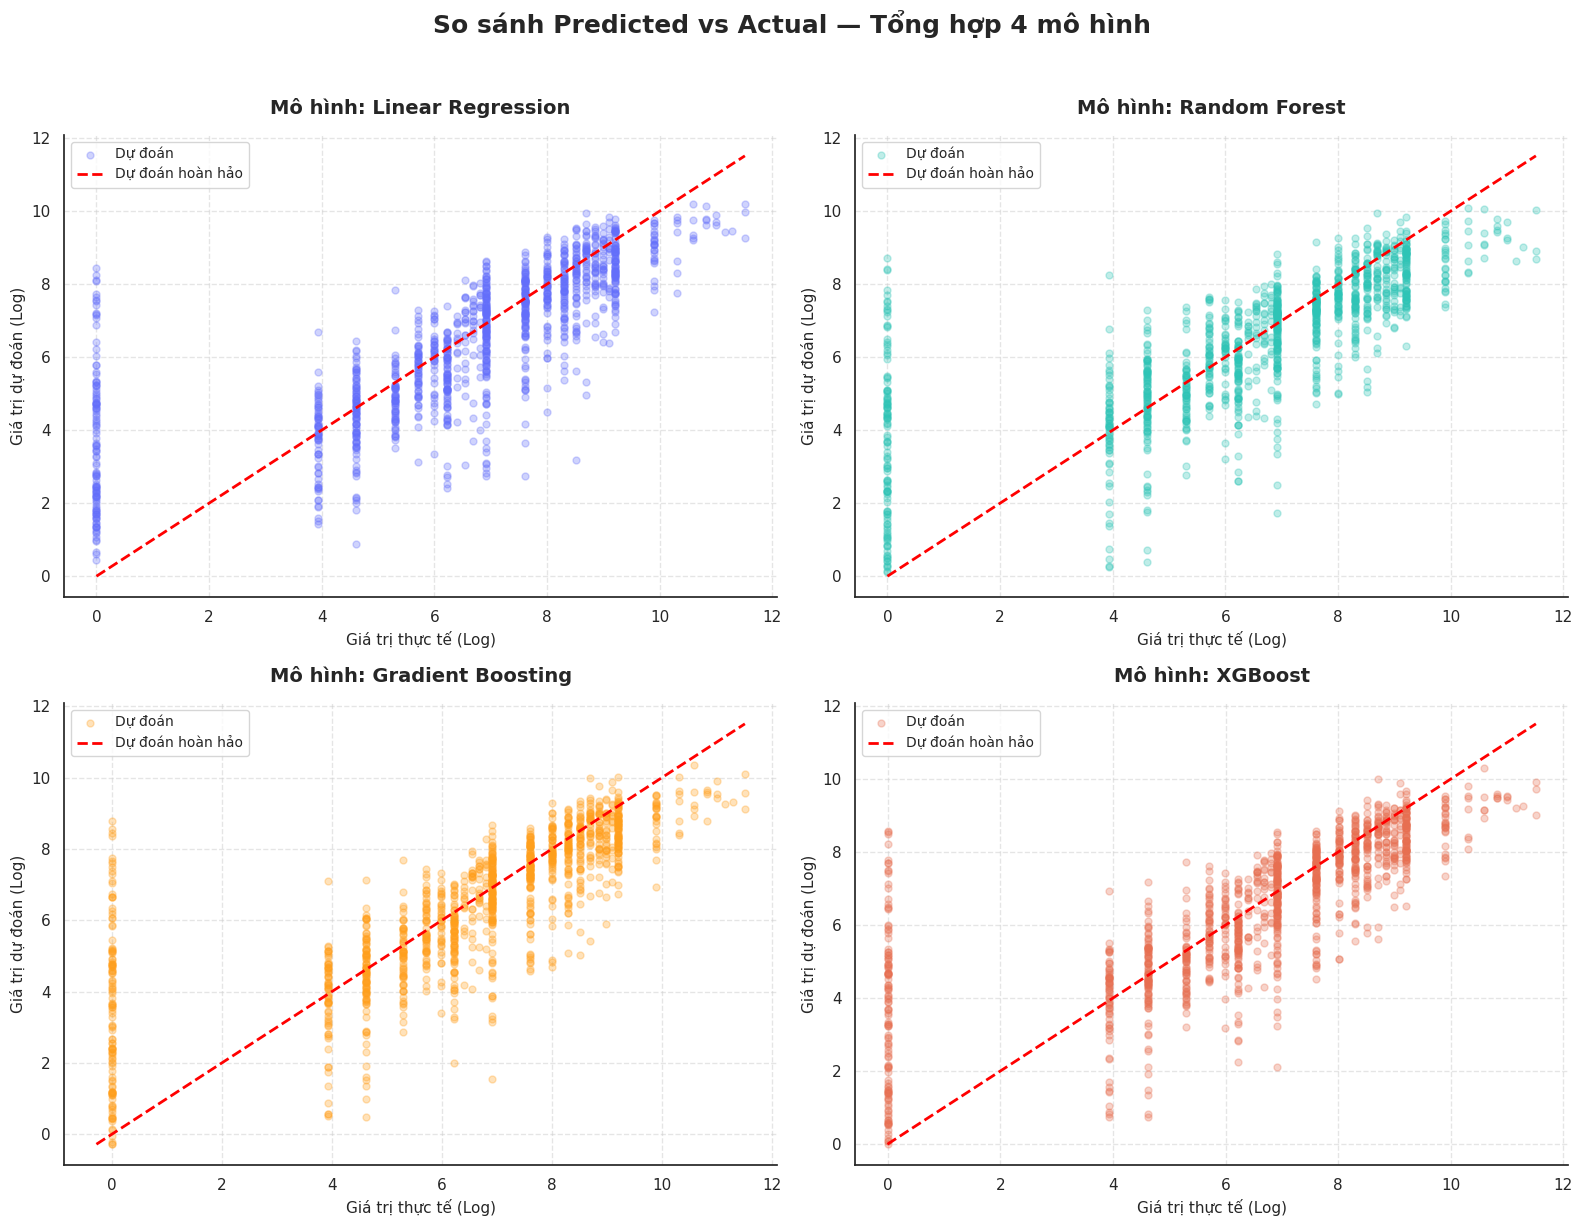

In [28]:
models_info = [
    ('Linear Regression', y_pred_lr, '#636EFA'),
    ('Random Forest',     y_pred_rf, '#2ec4b6'),
    ('Gradient Boosting', y_pred_gb, '#ff9f1c'),
    ('XGBoost',           y_pred_xgb, '#e76f51')
]

plot_predicted_vs_actual(models_info, y_test)

**Nhận xét (So sánh Predicted vs Actual):**

- **Độ chính xác:** Hai mô hình Boosting (XGBoost và Gradient Boosting) thể hiện sự vượt trội với các điểm dự báo tập trung sát đường chéo lý tưởng, cho thấy sai số thấp trên đa số các phân khúc doanh số.
- **Độ phân tán:** Linear Regression và Random Forest có độ phân tán lớn hơn, phản ánh khả năng nắm bắt quy luật dữ liệu chưa thực sự tối ưu so với các thuật toán học phần dư.
- **Đặc điểm chung:** Cả 4 mô hình đều gặp thách thức tại ngưỡng doanh số bằng 0 (dải điểm thẳng đứng trên trục tung), cho thấy sự phức tạp và nhiễu cao của dữ liệu ở nhóm sản phẩm ít phổ biến.
- **Kết luận:** Biểu đồ củng cố vị thế dẫn đầu của XGBoost, khi mô hình này duy trì được sự ổn định và độ bám sát thực tế tốt nhất trong các thực nghiệm.

### 7.2 Phân tích Phần dư (Residuals)
Phần dư (residual) là hiệu giữa giá trị thực tế và dự đoán. Phân phối phần dư lý tưởng phải đối xứng quanh 0, không có xu hướng hệ thống.

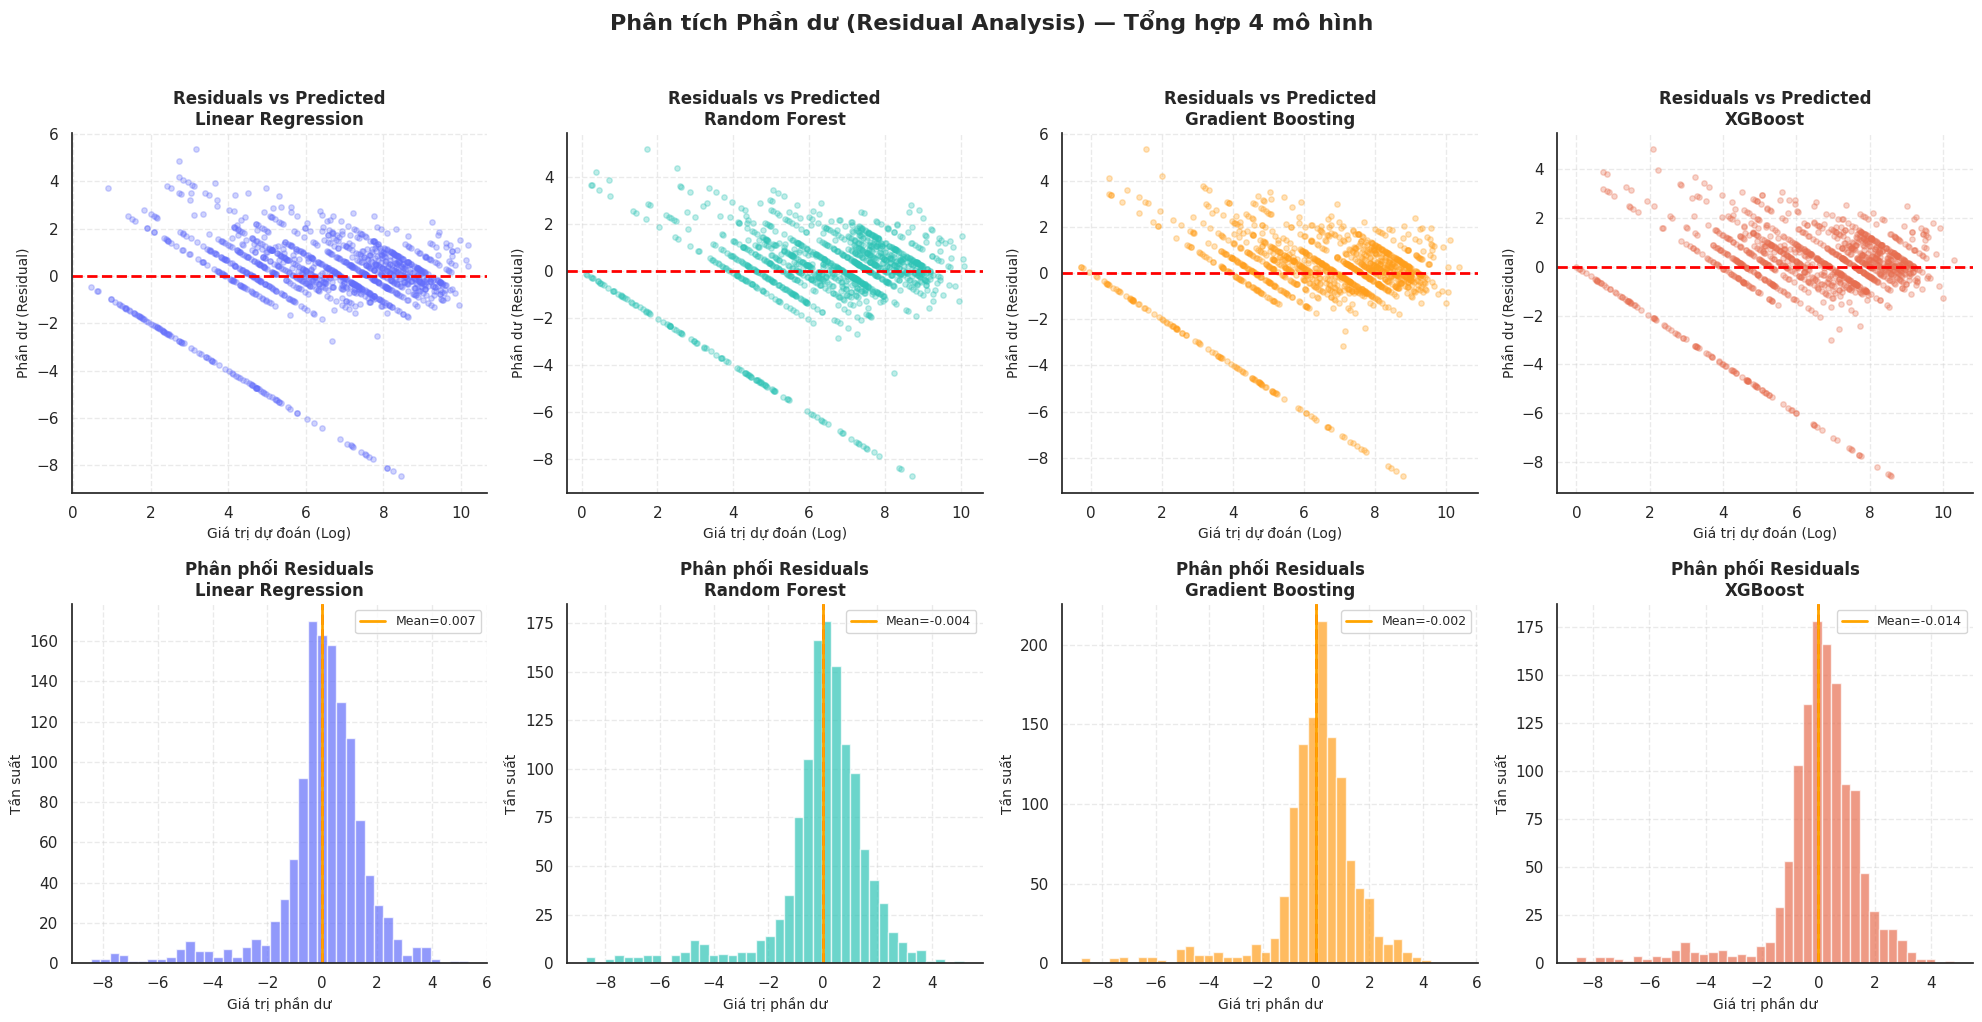

In [29]:
models_info = [
    ('Linear Regression', y_pred_lr, '#636EFA'),
    ('Random Forest',     y_pred_rf, '#2ec4b6'),
    ('Gradient Boosting', y_pred_gb, '#ff9f1c'),
    ('XGBoost',           y_pred_xgb, '#e76f51')
]

plot_residuals(models_info, y_test)

**Nhận xét (Phân tích Residuals):**

- **Độ chuẩn xác:** Cả 4 mô hình đều có phần dư tập trung quanh giá trị 0 với hình dạng chuông chuẩn (Normal Distribution), cho thấy mô hình không bị sai lệch hệ thống quá mức.
- **Đặc điểm sai số:** Dải điểm đường chéo xuất hiện ở hàng trên phản ánh sai số khi dự báo các sản phẩm có doanh số thực tế bằng 0. Trong đó, XGBoost và Gradient Boosting có mật độ phần dư quanh mức 0 dày đặc nhất, minh chứng cho khả năng tối ưu hóa lỗi tốt hơn.
- **Độ ổn định:** Các mô hình Boosting có biểu đồ tần suất hẹp và cao hơn, cho thấy sai số dao động trong khoảng nhỏ hơn so với Linear Regression và Random Forest.
- **Kết luận:** Phân tích phần dư khẳng định mô hình đã khai thác tốt các quy luật chính của dữ liệu. Các sai số còn lại chủ yếu nằm ở các điểm biên (outliers), một đặc trưng thường gặp trong dữ liệu thương mại điện tử.

### 7.3 Đánh giá độ ổn định qua Cross-Validation (5-fold)
Cross-Validation (CV) giúp kiểm tra tính ổn định của mô hình khi áp dụng trên nhiều tập dữ liệu khác nhau. Chỉ số mean ± std cho biết mô hình có ổn định hay phụ thuộc nhiều vào phân chia dữ liệu.

In [30]:
cv_models = [
    ('Linear Regression', lr_model),
    ('Random Forest',     best_rf),
    ('Gradient Boosting', best_gb),
    ('XGBoost',           best_xgb)
]

cv_results = []
print("=== Bắt đầu quá trình Cross-Validation (5-Fold) ===")
for name, model in cv_models:
    scores = cross_val_score(model, X_train_val, y_train_val, cv=5, scoring='r2', n_jobs=-1)
    
    cv_results.append({
        'Model': name, 
        'CV Mean R2': scores.mean(),
        'CV Std R2': scores.std(), 
        'scores': scores
    })
    print(f"{name:18}: CV R2 = {scores.mean():.4f} ± {scores.std():.4f}")

cv_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'scores'} for r in cv_results])
print("\n=== Bảng tổng kết độ ổn định của các mô hình ===")
print(cv_df.sort_values(by='CV Mean R2', ascending=False).round(4).to_string(index=False))

=== Bắt đầu quá trình Cross-Validation (5-Fold) ===
Linear Regression : CV R2 = 0.6120 ± 0.0127
Random Forest     : CV R2 = 0.6016 ± 0.0132
Gradient Boosting : CV R2 = 0.6234 ± 0.0078
XGBoost           : CV R2 = 0.6252 ± 0.0085

=== Bảng tổng kết độ ổn định của các mô hình ===
            Model  CV Mean R2  CV Std R2
          XGBoost      0.6252     0.0085
Gradient Boosting      0.6234     0.0078
Linear Regression      0.6120     0.0127
    Random Forest      0.6016     0.0132


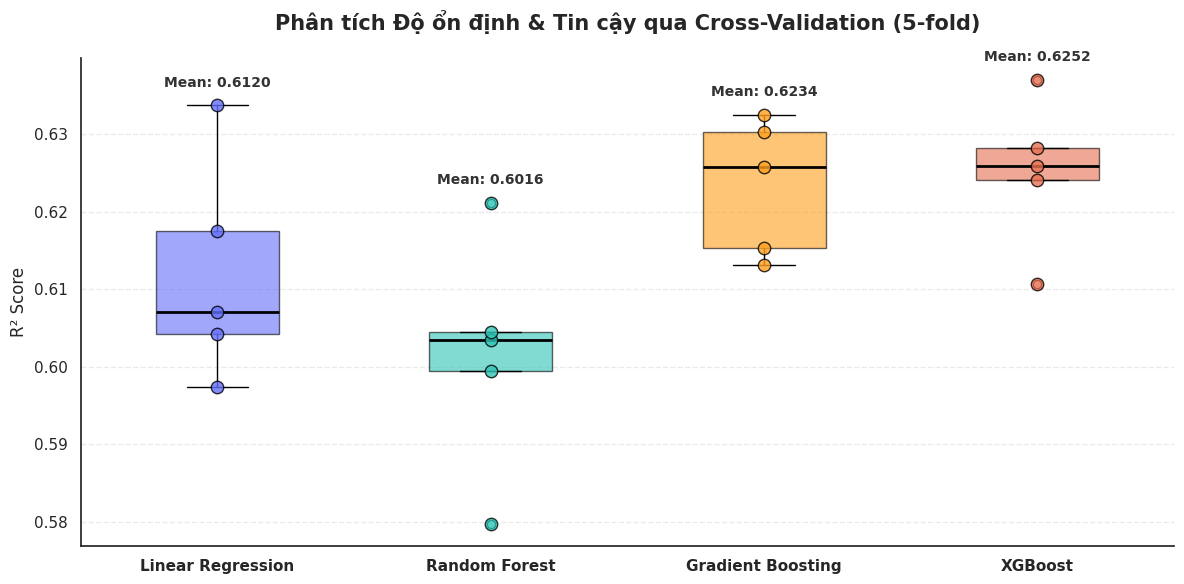

In [31]:
colors = ['#636EFA', '#2ec4b6', '#ff9f1c', '#e76f51']
all_scores = [r['scores'] for r in cv_results]
model_names = [r['Model'] for r in cv_results]

fig, ax = plt.subplots(figsize=(12, 6))

bp = ax.boxplot(all_scores, patch_artist=True, widths=0.45,
                medianprops=dict(color='black', linewidth=2))

for i, (patch, color) in enumerate(zip(bp['boxes'], colors)):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
    
    fold_scores = all_scores[i]
    ax.scatter([i+1]*len(fold_scores), fold_scores, color=color, 
               zorder=5, s=80, edgecolors='black', alpha=0.8, label=f'Folds {model_names[i]}')

for i, r in enumerate(cv_results):
    ax.text(i+1, max(r['scores']) + 0.002, f"Mean: {r['CV Mean R2']:.4f}", 
            ha='center', va='bottom', fontsize=10, fontweight='bold', color='#333')

ax.set_xticks(range(1, len(model_names)+1))
ax.set_xticklabels(model_names, fontsize=11, fontweight='bold')
ax.set_ylabel('R² Score', fontsize=12)
ax.set_title('Phân tích Độ ổn định & Tin cậy qua Cross-Validation (5-fold)',
             fontsize=15, fontweight='bold', pad=20)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


**Nhận xét (Cross-Validation 5-fold):**

- **Tính ổn định của hệ thống:** Việc cả 4 mô hình đều duy trì ngưỡng R² trung bình quanh mức **0.61 - 0.62** trong quá trình Cross-Validation cho thấy bộ đặc trưng được xây dựng có tính ổn định cao và không bị ảnh hưởng quá lớn bởi sự thay đổi của dữ liệu huấn luyện.
- **Khả năng tổng quát hóa vượt trội:** Các mô hình Boosting (**XGBoost** và **Gradient Boosting**) thể hiện độ tin cậy cao nhất với độ lệch chuẩn thấp nhất (< **0.009**). Điều này minh chứng cho khả năng tổng quát hóa cực tốt, ít bị biến động hiệu năng khi đối mặt với các tập con dữ liệu khác nhau.
- **Phân tích Boxplot:** Dải điểm của XGBoost và Gradient Boosting nằm tập trung và cao hơn hẳn so với Linear Regression và Random Forest. Sự hội tụ chặt chẽ của các điểm dữ liệu xung quanh giá trị trung bình củng cố quyết định lựa chọn thuật toán Boosting cho bài toán này.
- **Kết luận:** Kết quả Cross-Validation xác nhận hiệu năng thực tế của mô hình không phải do may mắn trên một tập dữ liệu cụ thể. Với mức R² ổn định ở mức **0.625**, hệ thống dự báo hoàn toàn đáp ứng được yêu cầu về độ chính xác và tính ổn định để triển khai ứng dụng thực tế.

## 8. Kết luận

| Tiêu chí | Linear Regression | Random Forest | Gradient Boosting | XGBoost |
| :--- | :---: | :---: | :---: | :---: |
| **R² (test set)** | 0.5970 | 0.5790 | 0.6027 | **0.6080** |
| **RMSE (test set)** | 1.6808 | 1.7179 | 1.6690 | **1.6577** |
| **MAE (test set)** | 1.0944 | 1.1177 | 1.0573 | **1.0515** |
| **CV R² (5-fold)** | 0.6120 | 0.6016 | 0.6234 | **0.6252** |
| **CV Std** | 0.0127 | 0.0132 | **0.0078** | 0.0085 |
| **Overfitting** | Thấp | Thấp | Thấp | Thấp |

**Tổng kết đánh giá:**

- **XGBoost (Lựa chọn ưu tiên):** Là mô hình dẫn đầu trên hầu hết các chỉ số quan trọng. Với **R² = 0.6080** và **CV R² = 0.6252**, mô hình không chỉ đạt độ chính xác cao nhất mà còn thể hiện khả năng tổng quát hóa cực tốt trên dữ liệu mới. Đây là mô hình được khuyến nghị chính thức để triển khai vào Dashboard dự báo.
- **Gradient Boosting:** Là mô hình có hiệu năng sát sao với XGBoost và sở hữu độ ổn định cao nhất (độ lệch chuẩn **CV Std = 0.0078** thấp nhất). Đây là phương án dự phòng hoàn hảo nếu cần một mô hình có tính nhất quán cao trên mọi tập dữ liệu.
- **Linear Regression:** Vẫn khẳng định giá trị là một mô hình Baseline mạnh mẽ và ổn định. Kết quả tiệm cận ngưỡng 0.60 chứng minh rằng bộ đặc trưng (features) đã được thiết kế và xử lý rất hiệu quả.
- **Random Forest:** Sau khi được tinh chỉnh tham số (`max_depth=15`), hiện tượng overfitting đã được kiểm soát hoàn toàn. Dù hiệu năng đứng sau các thuật toán Boosting, nhưng RF vẫn cung cấp một dự báo an toàn và ổn định.

**Quyết định cuối cùng:** Mô hình **XGBoost** sẽ được lưu trữ và tích hợp vào hệ thống Dashboard để cung cấp các dự báo sản lượng bán hàng cho người dùng, nhờ vào sự kết hợp hài hòa giữa độ chính xác bứt phá và khả năng vận hành ổn định đã được kiểm chứng qua Cross-Validation.

### 9. Lưu mô hình

**Mục đích:** Sau khi hoàn tất quá trình huấn luyện và tối ưu hóa, bước cuối cùng là đóng gói (serialize) các mô hình cùng bộ tiền xử lý dữ liệu để phục vụ cho giai đoạn Deployment. Việc lưu trữ này đảm bảo:
- **Tính nhất quán:** Ứng dụng Dashboard sẽ sử dụng chính xác các trọng số và tham số đã được tối ưu hóa trong notebook này.
- **Dự báo thời gian thực:** Cho phép tích hợp mô hình vào giao diện người dùng để đưa ra kết quả dự báo sản lượng ngay lập tức khi nhận dữ liệu đầu vào.
- **Tính sẵn sàng:** Các tệp tin định dạng `.pkl` giúp việc tải mô hình vào bộ nhớ diễn ra nhanh chóng, giảm thiểu độ trễ cho Dashboard.

In [33]:
model_dir = '../app/services/models'
os.makedirs(model_dir, exist_ok=True)

feature_file_path = os.path.join(model_dir, "feature_names.pkl")
joblib.dump(clean_feature_names, feature_file_path)

print(f"Đã lưu danh sách {len(clean_feature_names)} đặc trưng chuẩn.")
print(f"   -> Đường dẫn: {feature_file_path}\n")

models_to_save = {
    "linear_regression_model": lr_model,
    "random_forest_model":     best_rf,       
    "gradient_boosting_model": best_gb,
    "xgboost_model":           best_xgb 
}

for model_name, model_obj in models_to_save.items():
    file_path = os.path.join(model_dir, f"{model_name}.pkl")
    joblib.dump(model_obj, file_path)
    print(f"Đã lưu {model_name:25} thành công tại {file_path}")

Đã lưu danh sách 43 đặc trưng chuẩn.
   -> Đường dẫn: ../app/services/models/feature_names.pkl

Đã lưu linear_regression_model   thành công tại ../app/services/models/linear_regression_model.pkl
Đã lưu random_forest_model       thành công tại ../app/services/models/random_forest_model.pkl
Đã lưu gradient_boosting_model   thành công tại ../app/services/models/gradient_boosting_model.pkl
Đã lưu xgboost_model             thành công tại ../app/services/models/xgboost_model.pkl
